<a href="https://colab.research.google.com/github/rishis777/object-recognition-Ai-agent-/blob/main/Football_match_predicition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install liac-arff pandas

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=207b6d115738ba84988bd1665f8438297ed102c7992d077824f9ca2aea4f869d
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [ ]:

from google.colab import files
uploaded = files.upload()

Saving matches.csv to matches.csv


In [ ]:
import pandas as pd
import arff  # liac-arff

# Replace 'yourfile.csv' with the name of your uploaded file
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)

# Prepare ARFF data
arff_data = {
    'description': '',
    'relation': 'my_relation',
    'attributes': [],
    'data': df.values.tolist()
}
# Infer attribute types (all as 'REAL' by default, modify if needed)
for column in df.columns:
    dtype = df[column].dtype
    if dtype == object:
        # For categorical data, get unique values
        unique_vals = df[column].dropna().unique().tolist()
        arff_data['attributes'].append((column, unique_vals))
    else:
        arff_data['attributes'].append((column, 'REAL'))

# Save to .arff file
arff_file_name = csv_file.replace('.csv', '.arff')
with open(arff_file_name, 'w') as f:
    arff.dump(arff_data, f)

# Step 4: Download the .arff file
files.download(arff_file_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# 1. Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 2. Load the dataset
df = pd.read_csv("/content/matches.csv")  # 📁 Make sure 'matches.csv' is in your working folder

# 3. Preprocessing - Remove rows where important data is missing
df = df.dropna(subset=['gf', 'xg', 'poss'])  # gf = Goals For

# 4. Convert 'venue' column to numerical values (Home = 1, Away = 0)
df['venue'] = df['venue'].map({'Home': 1, 'Away': 0})

# 5. Define input features (X) and output/target (y)
X = df[['xg', 'poss', 'venue']]  # Features: Expected Goals, Possession, Venue
y = df['gf']                    # Target: Goals Scored

# 6. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Create Linear Regression model and train it
model = LinearRegression()
model.fit(X_train, y_train)

# 8. Predict goals for test data
y_pred = model.predict(X_test)

# 9. Evaluate the model
mse = mean_squared_error(y_test, y_pred)

# 10. Print model results
print("📊 Mean Squared Error (MSE):", round(mse, 2))
print("📈 Model Coefficients:", model.coef_)        # xg, poss, venue
print("📍 Intercept:", model.intercept_)


📊 Mean Squared Error (MSE): 1.14
📈 Model Coefficients: [ 0.99603457 -0.00606255  0.0187211 ]
📍 Intercept: 0.347610900385501


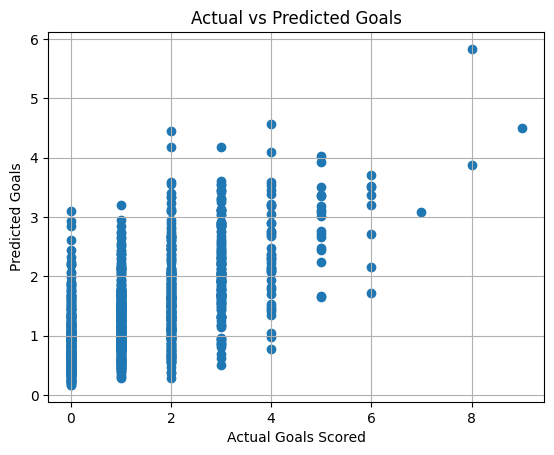

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Goals Scored")
plt.ylabel("Predicted Goals")
plt.title("Actual vs Predicted Goals")
plt.grid(True)
plt.show()

Intercept: 0.347610900385501
Coefficients (xg, poss, venue): [ 0.99603457 -0.00606255  0.0187211 ]
Mean Squared Error: 1.140619866959261
R² Score: 0.38778311769687346


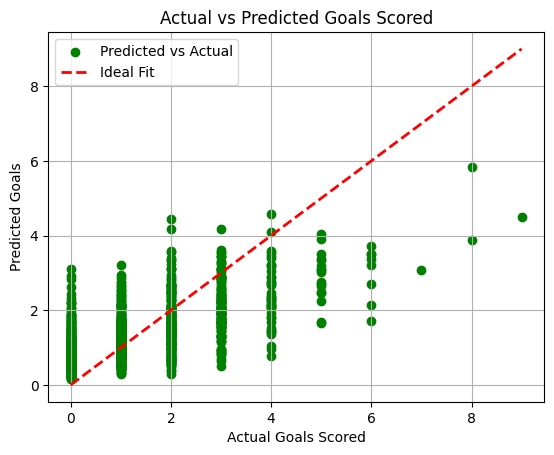

In [9]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Load dataset
df = pd.read_csv("/content/matches.csv")

# 3. Clean data - remove rows with missing values
df = df.dropna(subset=['gf', 'xg', 'poss', 'venue'])

# 4. Encode categorical variable 'venue' (Home = 1, Away = 0)
df['venue'] = df['venue'].map({'Home': 1, 'Away': 0})

# 5. Define features and target
X = df[['xg', 'poss', 'venue']]
y = df['gf']

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 8. Predict
y_pred = model.predict(X_test)

# 9. Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Intercept: {model.intercept_}")
print(f"Coefficients (xg, poss, venue): {model.coef_}")
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# 10. Visualization - Actual vs Predicted
plt.scatter(y_test, y_pred, color='green', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Actual Goals Scored")
plt.ylabel("Predicted Goals")
plt.title("Actual vs Predicted Goals Scored")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# prompt: pythonCopyEditimport pandas as pdfrom sklearn.model_selection import train_test_splitfrom sklearn.linear_model import LinearRegressionfrom sklearn.metrics import mean_squared_error
#  Load and preprocessdf = pd.read_csv("/content/matches.csv")
# df = df.dropna(subset=['gf', 'xg', 'poss'])
# # Encode categorical variablesdf['venue'] = df['venue'].map({'Home': 1, 'Away': 0})
# X = df[['xg', 'poss', 'venue']]  # Featuresy = df['gf']  # Target# Split dataX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# # Train modelmodel = LinearRegression()
# model.fit(X_train, y_train)
# # Predict & evaluatey_pred = model.predict(X_test)print("MSE:", mean_squared_error(y_test, y_pred))print("Coefficients:", model.coef_) what is error generate new code

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load and preprocess
df = pd.read_csv("/content/matches.csv")
df = df.dropna(subset=['gf', 'xg', 'poss', 'venue']) # Ensure 'venue' is also included in dropna

# Encode categorical variables
df['venue'] = df['venue'].map({'Home': 1, 'Away': 0})

# Define features (X) and target (y)
X = df[['xg', 'poss', 'venue']]  # Features
y = df['gf']  # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Added random_state for reproducibility

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)
print("Coefficients:", model.coef_)


MSE: 1.140619866959261
Coefficients: [ 0.99603457 -0.00606255  0.0187211 ]


In [11]:
pip install seaborn


In [12]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


    xg  xga  poss  sh  sot  Cluster
0  1.9  0.6    65  13    8        0
1  0.9  2.9    72  16    5        0
2  1.2  2.4    49  23    1        1
3  1.3  0.9    58  13    5        2
4  1.0  0.3    69  14    7        0


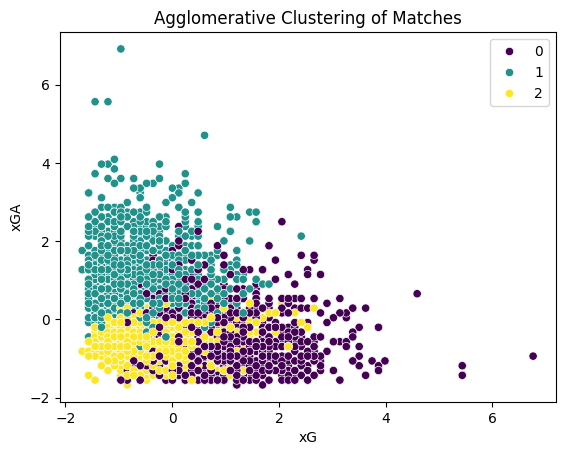

In [13]:
df = pd.read_csv("/content/matches.csv")  # Replace with your actual file path
features = df[['xg', 'xga', 'poss', 'sh', 'sot']]  # select columns
features = features.dropna()  # remove rows with missing values (important)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
cluster = AgglomerativeClustering(n_clusters=3)  # 3 groups
labels = cluster.fit_predict(scaled_features)
features['Cluster'] = labels
print(features.head())  # to see the clusters
sns.scatterplot(x=scaled_features[:, 0], y=scaled_features[:, 1], hue=labels, palette='viridis')
plt.xlabel("xG")
plt.ylabel("xGA")
plt.title("Agglomerative Clustering of Matches")
plt.show()


In [14]:
import numpy as np
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(1762), np.int64(1): np.int64(1501), np.int64(2): np.int64(1525)}


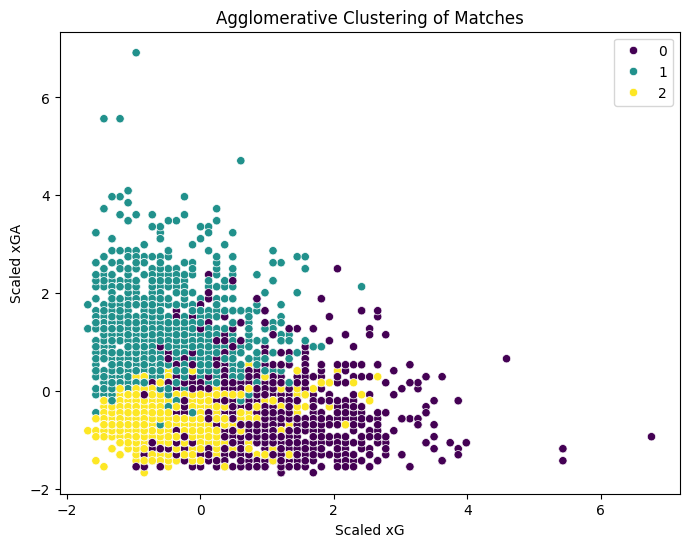

{np.int64(0): np.int64(1762), np.int64(1): np.int64(1501), np.int64(2): np.int64(1525)}


In [15]:
# prompt: pythonCopyEditfrom sklearn.cluster import AgglomerativeClusteringfrom sklearn.preprocessing import StandardScalerimport matplotlib.pyplot as pltimport seaborn as sns
# # Select numeric featuresfeatures = df[['xg', 'xga', 'poss', 'sh', 'sot']]
# features = features.dropna()
# # Standardize datascaler = StandardScaler()
# scaled_features = scaler.fit_transform(features)
# # Apply Agglomerative Clusteringcluster = AgglomerativeClustering(n_clusters=3)
# labels = cluster.fit_predict(scaled_features)
# # Visualize clusterssns.scatterplot(x=scaled_features[:, 0], y=scaled_features[:, 1], hue=labels)
# plt.xlabel("xG")
# plt.ylabel("xGA")
# plt.title("Agglomerative Clustering of Matches")
# plt.show() what is error generate new code

import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your dataset
df = pd.read_csv("/content/matches.csv")

# Select features and handle missing data
features = df[['xg', 'xga', 'poss', 'sh', 'sot']]
features = features.dropna()  # Remove rows with any missing values in selected features

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=3) # You can adjust the number of clusters
labels = cluster.fit_predict(scaled_features)

# Visualize the clusters
plt.figure(figsize=(8, 6)) # Adjust figure size for better visualization
sns.scatterplot(x=scaled_features[:, 0], y=scaled_features[:, 1], hue=labels, palette="viridis")
plt.xlabel("Scaled xG") # More descriptive label
plt.ylabel("Scaled xGA")
plt.title("Agglomerative Clustering of Matches")
plt.show()

# Print cluster sizes
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))


In [16]:
pip install mlxtend


In [17]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
df = pd.read_csv("/content/matches.csv")  # Use your file path
df_apriori = df[['venue', 'formation', 'result']].dropna()
df_apriori = df_apriori.astype(str)  # Convert all values to string
df_apriori = df[['venue', 'formation', 'result']].dropna()
df_apriori = df_apriori.astype(str)  # Convert all values to string
transactions = df_apriori.values.tolist()
[['Home', '4-3-3', 'Win'], ['Away', '3-5-2', 'Draw'], ...]
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)
print(frequent_itemsets.head())
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print(rules[['antecedents', 'consequents', 'support', 'confidence']])


    support   itemsets
0  0.023601  (3-4-1-2)
1  0.114453    (3-4-3)
2  0.055556    (3-5-2)
3  0.053885  (4-1-4-1)
4  0.288638  (4-2-3-1)
      antecedents consequents   support  confidence
0         (3-4-3)      (Away)  0.058688    0.512774
1         (3-5-2)      (Away)  0.028613    0.515038
2         (3-5-2)         (L)  0.030075    0.541353
3       (4-1-4-1)      (Home)  0.028404    0.527132
4       (4-2-3-1)      (Home)  0.149541    0.518090
5         (4-3-3)      (Away)  0.107561    0.502439
6         (4-3-3)         (W)  0.111529    0.520976
7         (4-4-2)      (Home)  0.061821    0.507719
8             (D)      (Away)  0.112364    0.501398
9             (L)      (Away)  0.213033    0.560440
10            (W)      (Home)  0.221178    0.558839
11     (L, 3-4-3)      (Away)  0.022765    0.550505
12     (W, 3-4-3)      (Home)  0.024645    0.551402
13   (4-2-3-1, D)      (Away)  0.031746    0.510067
14   (L, 4-2-3-1)      (Away)  0.055138    0.540984
15   (W, 4-2-3-1)      (Home) 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
rules.to_csv("association_rules.csv", index=False)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Step 1: Load dataset
df = pd.read_csv("/content/matches.csv")

# Step 2: Select and clean categorical columns
df_apriori = df[['venue', 'formation', 'result']].dropna()
df_apriori = df_apriori.astype(str)

# Step 3: Convert to list of transactions
transactions = df_apriori.values.tolist()

# Step 4: Encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Step 5: Run Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

# Step 6: Generate Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Step 7: Show rules
print(rules[['antecedents', 'consequents', 'support', 'confidence']])

# Optional: Save to CSV
rules.to_csv("association_rules.csv", index=False)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

      antecedents consequents   support  confidence
0         (3-4-3)      (Away)  0.058688    0.512774
1         (3-5-2)      (Away)  0.028613    0.515038
2         (3-5-2)         (L)  0.030075    0.541353
3       (4-1-4-1)      (Home)  0.028404    0.527132
4       (4-2-3-1)      (Home)  0.149541    0.518090
5         (4-3-3)      (Away)  0.107561    0.502439
6         (4-3-3)         (W)  0.111529    0.520976
7         (4-4-2)      (Home)  0.061821    0.507719
8             (D)      (Away)  0.112364    0.501398
9             (L)      (Away)  0.213033    0.560440
10            (W)      (Home)  0.221178    0.558839
11     (L, 3-4-3)      (Away)  0.022765    0.550505
12     (W, 3-4-3)      (Home)  0.024645    0.551402
13   (4-2-3-1, D)      (Away)  0.031746    0.510067
14   (L, 4-2-3-1)      (Away)  0.055138    0.540984
15   (W, 4-2-3-1)      (Home)  0.072264    0.580537
16     (4-3-3, L)      (Away)  0.036967    0.618881
17     (4-3-3, D)      (Home)  0.021512    0.502439
18     (4-3-

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Step 1: Load and prepare data
df = pd.read_csv("matches.csv")  # replace with your file name
df_apriori = df[['venue', 'formation', 'result']].dropna().astype(str)

# Step 2: Convert into transactions
transactions = df_apriori.values.tolist()

# Step 3: Encode transactions into binary format
te = TransactionEncoder()
df_encoded = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

# Step 4: Apply Apriori
min_support = 0.3
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Step 5: Generate Association Rules
min_confidence = 0.7
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# Step 6: Output results like Weka
print("=" * 50)
print("Apriori Algorithm Results")
print("=" * 50)
print(f"\nMinimum Support: {min_support}")
print(f"Minimum Confidence: {min_confidence}")
print(f"Number of Itemsets Found: {len(frequent_itemsets)}")
print("\nGenerated Sets of Large Itemsets:")
print("-" * 50)

for i in range(1, frequent_itemsets['itemsets'].str.len().max() + 1):
    count = frequent_itemsets[frequent_itemsets['itemsets'].str.len() == i].shape[0]
    print(f"Size of set of large itemsets L({i}): {count}")

print("\nBest Rules Found:")
print("-" * 50)
for idx, rule in rules.iterrows():
    antecedent = ", ".join(rule['antecedents'])
    consequent = ", ".join(rule['consequents'])
    conf = round(rule['confidence'], 2)
    lift = round(rule['lift'], 2)
    support = round(rule['support'], 2)
    print(f"{idx+1}. {antecedent} ==> {consequent}   <conf:({conf})> lift:({lift}) support:({support})")

print("\nStatus: OK ✅")


Apriori Algorithm Results

Minimum Support: 0.3
Minimum Confidence: 0.7
Number of Itemsets Found: 4

Generated Sets of Large Itemsets:
--------------------------------------------------
Size of set of large itemsets L(1): 4

Best Rules Found:
--------------------------------------------------

Status: OK ✅


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [21]:
# prompt: pythonCopyEditfrom mlxtend.frequent_patterns import apriori, association_rulesfrom mlxtend.preprocessing import TransactionEncoder
# # Convert match data into categorical (binned or string)df_apriori = df[['venue', 'formation', 'result']].dropna()
# df_apriori = df_apriori.astype(str)
# # Convert to list of liststransactions = df_apriori.values.tolist()
# # Encode transactionste = TransactionEncoder()
# te_ary = te.fit(transactions).transform(transactions)
# df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
# # Run Apriorifrequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)
# rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
# # View rules print(rules[['antecedents', 'consequents', 'support', 'confidence']])  what is error generate new code

# Step 1: Load and prepare data
df = pd.read_csv("/content/matches.csv")  # Replace with your file name
df_apriori = df[['venue', 'formation', 'result']].dropna().astype(str)

# Step 2: Convert into transactions
transactions = df_apriori.values.tolist()

# Step 3: Encode transactions into binary format
te = TransactionEncoder()
df_encoded = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

# Step 4: Apply Apriori
min_support = 0.02  # You can adjust this value
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Step 5: Generate Association Rules
min_confidence = 0.5  # You can adjust this value
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# Step 6: Output results
print(rules[['antecedents', 'consequents', 'support', 'confidence']])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

      antecedents consequents   support  confidence
0         (3-4-3)      (Away)  0.058688    0.512774
1         (3-5-2)      (Away)  0.028613    0.515038
2         (3-5-2)         (L)  0.030075    0.541353
3       (4-1-4-1)      (Home)  0.028404    0.527132
4       (4-2-3-1)      (Home)  0.149541    0.518090
5         (4-3-3)      (Away)  0.107561    0.502439
6         (4-3-3)         (W)  0.111529    0.520976
7         (4-4-2)      (Home)  0.061821    0.507719
8             (D)      (Away)  0.112364    0.501398
9             (L)      (Away)  0.213033    0.560440
10            (W)      (Home)  0.221178    0.558839
11     (L, 3-4-3)      (Away)  0.022765    0.550505
12     (W, 3-4-3)      (Home)  0.024645    0.551402
13   (4-2-3-1, D)      (Away)  0.031746    0.510067
14   (L, 4-2-3-1)      (Away)  0.055138    0.540984
15   (W, 4-2-3-1)      (Home)  0.072264    0.580537
16     (4-3-3, L)      (Away)  0.036967    0.618881
17     (4-3-3, D)      (Home)  0.021512    0.502439
18     (4-3-

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag